# Sensitivity Analysis for Uncertainty Importance Screening

In [141]:
from __future__ import annotations
import argparse
import os
import sys
import importlib
import warnings
import time
import numpy as np
import csv
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [142]:
# ── path fix ─────────────────────────────────────────────────────────────────
# parent_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
#sys.path.insert(0, parent_dir)

import openmdao.api as om
import qbit.constants as C
from qbit.constants import G, W_TOTAL_BOUNDS, V_INF_BOUNDS, R_BOUNDS, J_BOUNDS, S_W_BOUNDS

# ── matplotlib style (matches sensitivity_oat.py) ────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "lines.linewidth": 1.8, "lines.markersize": 6,
})

TYPE_COLORS = {
    "input": "#388bfd",
    "param": "#d29922",
    "model": "#a371f7",
}

In [143]:
# ── CLI ───────────────────────────────────────────────────────────────────────
parser = argparse.ArgumentParser()
parser.add_argument("--payload", type=float, default=3.0)
parser.add_argument("--range",   type=float, default=15.0, help="km one-way")
parser.add_argument("--nc",      type=int,   default=2)
parser.add_argument("--method",  type=str,   default="morris",
                    choices=["morris", "sobol", "both"],
                    help="Screening method (default: morris)")
parser.add_argument("--r",       type=int,   default=15,
                    help="Morris: number of trajectories (default 15)")
parser.add_argument("--p",       type=int,   default=6,
                    help="Morris: number of grid levels (default 6)")
parser.add_argument("--n",       type=int,   default=64,
                    help="Sobol: base sample count N (total runs = N*(2k+2))")
parser.add_argument("--seed",    type=int,   default=42)
args, _ = parser.parse_known_args()

PAYLOAD_KG  = args.payload
RANGE_M     = args.range * 1_000.0
N_C         = args.nc
METHOD      = args.method
R_MORRIS    = args.r
P_MORRIS    = args.p
N_SOBOL     = args.n
SEED        = args.seed
RANGE_KM    = int(RANGE_M / 1_000)
PAYLOAD_STR = f"{PAYLOAD_KG:g}"



In [144]:
PARAMS = [
    # attr              nominal    label                    type     lb          ub          justification
    ("RHO_AIR",         1.225,    "ρ_air",                "input", 1.040,      1.410),     # ±15%: ISA 0-2000m + temp variation
    ("T_HOVER",         60.0,     "t_hover",              "input", 30.0,       180.0),     # physical mission envelope, not %-based
    ("BETA_QBIT",       0.18,     "β_QBiT (frame frac.)", "param", 0.144,      0.216),     # ±20%: Raymer conceptual stage structural uncertainty
    ("ETA_HOVER",       0.65,     "η_hover",              "param", 0.550,      0.750),     # literature range small UAV rotors (Leishman 2006)
    ("CD0_WING",        0.01,     "CD0_wing",             "param", 0.008,      0.012),     # ±20%: conceptual-stage CFD/panel scatter
    ("E_OSWALD",        0.80,     "e_Oswald",             "param", 0.680,      0.920),     # ±15%: panel method uncertainty
    ("AR_FIXED",        8.0,      "AR",                   "input", 6.4,        9.6),       # ±20%: design space exploration
    ("SIGMA",           0.13,     "σ (solidity)",         "param", 0.104,      0.156),     # ±20%: manufacturing tolerance + design choice
    ("CD0_ROTOR",       0.012,    "CD0_rotor",            "param", 0.009,      0.015),     # ±20%: CFD/BEM scatter at conceptual stage
    ("KAPPA_MAX",       1.15,     "κ_max",                "param", 1.035,      1.265),     # ±10%: well-characterised inflow correction
    ("BATTERY_DENSITY", 158.0,    "ρ_bat (Wh/kg)",        "input", 126.0,      200.0),     # LiPo technology range 2024 (manufacturer data)
    ("BATTERY_EFF",     0.85,     "η_bat",                "param", 0.720,      0.980),     # ±15%, capped below 1.0: C-rate + temp effects
    ("K_MOTOR",         2.506e-4, "k_motor",              "model", 2.130e-4,   2.882e-4),  # ±15%: regression 95% prediction interval
    ("K_ESC",           3.594e-4, "k_ESC",                "model", 3.055e-4,   4.133e-4),  # ±15%: regression 95% prediction interval
    ("K_ROTOR_A",       0.7484,   "k_rotor_A",            "model", 0.636,      0.861),     # ±15%: regression 95% prediction interval
    ("K_ROTOR_B",       0.0403,   "k_rotor_B",            "model", 0.034,      0.046),     # ±15%: regression 95% prediction interval
    ("K_WING_A",       -0.0802,   "k_wing_A",             "model", -0.092,    -0.068),     # ±15%: regression 95% prediction interval
    ("K_WING_B",        2.2854,   "k_wing_B",             "model", 1.943,      2.628),     # ±15%: regression 95% prediction interval
    ("DL_MAX",          55.0,     "DL_MAX (disk load.)",  "param", 44.0,       66.0),      # ±20%: noise regs + structural assumption uncertainty
    ("BL_MAX",          80.0,     "BL_MAX (blade load.)", "param", 64.0,       96.0),      # ±20%: blade stall characterisation uncertainty
    ("CL_MAX",          1.0,      "CL_MAX (cruise CL)",   "param", 0.800,      1.200),     # ±20%: airfoil + flap assumption uncertainty
]

k = len(PARAMS)
LB = np.array([p[4] for p in PARAMS])
UB = np.array([p[5] for p in PARAMS])

In [145]:
# ── CONSTANTS HELPERS (mirrors sensitivity_oat.py) ────────────────────────────
def _restore_all() -> None:
    for attr, nominal, *_ in PARAMS:
        setattr(C, attr, nominal)


def _set_constants_from_array(x: np.ndarray) -> None:
    """Set all constants from a parameter vector x (physical units)."""
    for j, (attr, *_) in enumerate(PARAMS):
        setattr(C, attr, float(x[j]))


def _reload_qbit() -> None:
    """Reload all qbit submodules (except constants) to pick up patched values."""
    for name in list(sys.modules.keys()):
        if name.startswith("qbit.") and name != "qbit.constants":
            try:
                importlib.reload(sys.modules[name])
            except Exception:
                pass

In [146]:

# ── EVALUATOR: re-optimise W* (THE CORRECT EVALUATOR FOR UMDO SCREENING) ──────
def optimise_W(payload_kg: float, range_m: float, n_c: int) -> float:
    """
    Run the SLSQP optimiser with current C.* constants and return W*_total [N].

    This is the exact same function as sensitivity_oat.py::optimise(), keeping
    the design variables free so the design adapts to each parameter sample.
    The result is the *optimal* MTOM — the quantity whose sensitivity to
    uncertain parameters we are screening.
    """
    _reload_qbit()

    try:
        from qbit.models.qbit_model import build_qbit_model as _build
    except Exception:
        from qbit.models.qbit_model import build_qbit_model as _build

    prob = om.Problem(reports=None)
    prob.model = _build(payload_kg, range_m, n_c)

    prob.driver = om.ScipyOptimizeDriver()
    prob.driver.options["optimizer"] = "SLSQP"
    prob.driver.options["tol"]       = 1e-9
    prob.driver.options["maxiter"]   = 2000

    prob.model.add_design_var("W_total", lower=W_TOTAL_BOUNDS[0], upper=W_TOTAL_BOUNDS[1])
    prob.model.add_design_var("V_inf",   lower=V_INF_BOUNDS[0],   upper=V_INF_BOUNDS[1])
    prob.model.add_design_var("r",       lower=R_BOUNDS[0],        upper=R_BOUNDS[1])
    prob.model.add_design_var("J",       lower=J_BOUNDS[0],        upper=J_BOUNDS[1])
    prob.model.add_design_var("S_w",     lower=S_W_BOUNDS[0],      upper=S_W_BOUNDS[1])

    prob.model.add_objective("W_total")
    prob.model.add_constraint("weight_residual", equals=0.0)
    prob.model.add_constraint("disk_loading",    upper=C.DL_MAX)
    prob.model.add_constraint("blade_loading",   upper=C.BL_MAX)
    prob.model.add_constraint("cruise_CL",       upper=C.CL_MAX)

    prob.model.set_input_defaults("W_total", val=6.0 * G, units="N")
    prob.setup()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prob.run_driver()

    return float(prob.get_val("W_total")[0])

In [147]:

def evaluate(x: np.ndarray) -> float:
    """
    Evaluate W* [N] for a parameter vector x in physical space.
    Sets all constants, reloads qbit modules, then optimises.
    Returns NaN on failure so outlier detection can handle it.
    """
    _restore_all()
    _set_constants_from_array(x)
    try:
        W = optimise_W(PAYLOAD_KG, RANGE_M, N_C)
        # Sanity check: reject obviously broken results
        if W < 1.0 * G or W > 500.0 * G:
            return float("nan")
        return W
    except Exception as e:
        return float("nan")
    finally:
        _restore_all()


# ── BASELINE ──────────────────────────────────────────────────────────────────
def compute_baseline() -> float:
    _restore_all()
    W = optimise_W(PAYLOAD_KG, RANGE_M, N_C)
    return W

In [148]:

# ═════════════════════════════════════════════════════════════════════════════
# MORRIS METHOD
# ═════════════════════════════════════════════════════════════════════════════

def _morris_trajectory(k: int, p: int, rng: np.random.Generator) -> np.ndarray:
    """
    Generate one optimised Morris trajectory in [0,1]^k.

    Returns B* of shape (k+1, k). Successive rows differ in exactly one
    coordinate by ±Δ where Δ = p / (2*(p-1)).

    Reference: Morris (1991) Eq. 1-4; Campolongo (2007) improved sampling.
    """
    delta = p / (2.0 * (p - 1))

    # Random orientation matrix D* (diagonal ±1)
    D_star = np.diag(2 * rng.integers(0, 2, size=k) - 1)
    # Random permutation matrix P*
    perm = rng.permutation(k)
    P_star = np.eye(k, dtype=float)[perm]
    # Random base point x* in [0, 1-Δ]
    x_star = rng.uniform(0, 1.0 - delta, size=k)

    # Lower-triangular unit matrix
    B = np.tril(np.ones((k + 1, k), dtype=float), -1)
    J_col = np.ones((k + 1, 1))
    J_row = np.ones((1, k))

    B_star = (J_col @ x_star.reshape(1, k)
              + (delta / 2.0) * ((2.0 * B - J_col @ J_row) @ D_star @ P_star.T))
    # Clip to [0,1] to handle floating-point boundary issues
    return np.clip(B_star, 0.0, 1.0)


def _norm_to_physical(X_norm: np.ndarray) -> np.ndarray:
    """Scale from [0,1] to physical [lb, ub]."""
    return LB + X_norm * (UB - LB)


def run_morris(W_base: float) -> list[dict]:
    """
    Run Morris Elementary Effects screening.

    Returns list of dicts with keys:
        attr, label, type, nominal, mu_star, sigma, ee_vals
    """
    rng = np.random.default_rng(SEED)
    n_total = R_MORRIS * (k + 1)

    print(f"\n── Morris Elementary Effects ─────────────────────────────────────")
    print(f"   k={k} parameters, R={R_MORRIS} trajectories, p={P_MORRIS} levels")
    print(f"   Total optimiser calls: {n_total}")

    # ee_raw[j] = list of elementary effects for parameter j (in W* [N] / physical unit)
    ee_raw = [[] for _ in range(k)]
    n_fail = 0
    n_done = 0
    t0 = time.time()

    for tr in range(R_MORRIS):
        B_star = _morris_trajectory(k, P_MORRIS, rng)
        X_norm = B_star                           # already in [0,1]
        X_phys = _norm_to_physical(X_norm)        # physical values, shape (k+1, k)

        # Evaluate W* at each of the k+1 points in this trajectory
        Y = np.full(k + 1, np.nan)
        for i in range(k + 1):
            n_done += 1
            elapsed = time.time() - t0
            eta = (elapsed / n_done) * (n_total - n_done) if n_done > 1 else 0.0
            print(f"  [{n_done:>4}/{n_total}]  trajectory {tr+1:>2}/{R_MORRIS}  "
                  f"point {i+1:>2}/{k+1}  ETA {eta/60:.1f} min …",
                  end="\r", flush=True)
            Y[i] = evaluate(X_phys[i])
            if np.isnan(Y[i]):
                n_fail += 1

        # Compute elementary effects from this trajectory
        # The trajectory B_star has each step changing exactly one parameter.
        # We identify which parameter changed at each step by comparing rows.
        for step in range(k):
            diff_norm = X_norm[step + 1] - X_norm[step]
            j = int(np.argmax(np.abs(diff_norm)))    # which parameter moved
            delta_phys = X_phys[step + 1, j] - X_phys[step, j]
            if abs(delta_phys) < 1e-15:
                continue
            if np.isnan(Y[step]) or np.isnan(Y[step + 1]):
                continue
            EE = (Y[step + 1] - Y[step]) / delta_phys    # [N / physical_unit]
            ee_raw[j].append(EE)

    print(f"\n  Morris done: {n_done} evaluations, {n_fail} failures ({n_fail/n_done*100:.1f}%)")

    # Compute Morris statistics
    results = []
    for j, (attr, nominal, label, typ, lb, ub) in enumerate(PARAMS):
        vals = np.array(ee_raw[j])
        if len(vals) == 0:
            mu_star, sigma, ee_norm = 0.0, 0.0, []
        else:
            # Normalise: convert dimensional EE to elasticity
            # μ* = mean|EE| * (range_p / W_base) → dimensionless
            range_p = ub - lb
            ee_norm = [v * range_p / W_base for v in vals]
            mu_star = float(np.mean(np.abs(ee_norm)))
            sigma   = float(np.std(ee_norm))

        results.append({
            "attr": attr, "label": label, "type": typ, "nominal": nominal,
            "mu_star": mu_star, "sigma": sigma, "ee_vals": ee_norm,
            "n_ee": len(ee_norm),
        })

    results.sort(key=lambda r: r["mu_star"], reverse=True)
    return results

In [149]:
# ═════════════════════════════════════════════════════════════════════════════
# PRINT TABLES
# ═════════════════════════════════════════════════════════════════════════════

def print_morris_table(results: list[dict], W_base: float) -> None:
    SEP = "=" * 80
    print(f"\n{SEP}")
    print(f"  Morris (EE) Screening  —  W*_base = {W_base/G:.4f} kg  "
          f"[re-optimised evaluator]")
    print(f"  Mission: payload={PAYLOAD_KG} kg  R={RANGE_M/1e3:.0f} km  "
          f"n_c={N_C}  |  R={R_MORRIS} trajectories, p={P_MORRIS} levels")
    print(SEP)
    print(f"  {'Rk':>2}  {'Parameter':30s}  {'Type':6s}  "
          f"{'μ*':>8}  {'σ':>8}  {'σ/μ*':>7}  Decision")
    print("  " + "─" * 72)
    for i, r in enumerate(results, 1):
        ratio = r["sigma"] / r["mu_star"] if r["mu_star"] > 1e-10 else 0.0
        if r["mu_star"] < 0.02:
            decision = "FREEZE"
        elif r["mu_star"] < 0.10:
            decision = "marginal"
        else:
            decision = "KEEP  ◀" + ("◀ nonlinear" if ratio > 1.0 else "")
        print(f"  {i:>2}  {r['label']:30s}  {r['type']:6s}  "
              f"{r['mu_star']:>8.4f}  {r['sigma']:>8.4f}  {ratio:>7.2f}  {decision}")
    print(SEP)
    print("  μ* = mean|EE| × (range_p / W*_base)  — normalised importance")
    print("  σ  = std(EE_norm)  — nonlinearity / parameter interactions")
    print("  σ/μ* > 1 → nonlinear or interacting with other parameters")
    print(f"{SEP}\n")

In [150]:
def plot_morris(results: list[dict], W_base: float) -> None:
    """
    Two-panel Morris plot stacked vertically:
    Top:    Clean ranked bar chart of μ* (importance)
    Bottom: Clean μ* vs σ scatter with the identity line as a structural reference
    """
    labels  = [r["label"]   for r in results]
    mu_star = [r["mu_star"] for r in results]
    sigma   = [r["sigma"]   for r in results]
    colors  = [TYPE_COLORS.get(r["type"], "gray") for r in results]

    # Vertical stack layout (2 rows, 1 column)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, max(10, len(labels) * 0.75)))

    # ── Top Panel: Ranked Bar Chart ───────────────────────────────────────
    y    = np.arange(len(labels))
    xmax = max(mu_star) if max(mu_star) > 0 else 1.0
    ax1.barh(y, mu_star, color=colors, height=0.62, edgecolor="none")
    
    for yi, v in zip(y, mu_star):
        if v > 0:
            ax1.text(v + xmax * 0.01, yi, f"{v:.4f}", va="center", fontsize=10)
            
    ax1.set_yticks(y)
    ax1.set_yticklabels(labels, fontsize=10)
    ax1.set_xlabel("μ* = mean|EE| (normalised importance)", fontsize=11)
    ax1.set_title(f"Morris Screening — Importance Ranking (W*_base = {W_base/G:.3f} kg)", fontsize=13, pad=12)
    ax1.invert_yaxis()
    ax1.set_xlim(0, xmax * 1.15)
    
    # Despine top and right borders for crisp design
    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)
        ax2.spines[spine].set_visible(False)

    # ── Bottom Panel: μ* vs σ Scatter ──────────────────────────────────────
    for r, col in zip(results, colors):
        ax2.scatter(r["mu_star"], r["sigma"], color=col, s=75, zorder=3, edgecolor="none")
        if r["mu_star"] > 0.005 or r["sigma"] > 0.005:
            ax2.annotate(r["label"], (r["mu_star"], r["sigma"]),
                         fontsize=9, xytext=(5, 5), textcoords="offset points")

    lim = max(max(mu_star), max(sigma)) * 1.05 if max(mu_star) > 0 else 1.0
    
    # Structural identity reference line (σ = μ*)
    ax2.plot([0, lim], [0, lim], color="#555555", lw=1.0, ls="--", zorder=1, label="σ = μ*")
    
    ax2.set_xlabel("μ* (importance)", fontsize=11)
    ax2.set_ylabel("σ (nonlinearity / interactions)", fontsize=11)
    ax2.set_title("Morris Parameter Dynamics: Importance vs Nonlinearity", fontsize=13, pad=12)
    ax2.set_xlim(0, lim)
    ax2.set_ylim(0, lim)
    ax2.legend(fontsize=10, loc="upper left", frameon=False)

    # ── Legend Block ───────────────────────────────────────────────────────
    handles = [mpatches.Patch(fc=TYPE_COLORS[t], label=lb)
               for t, lb in [("input", "Input / Mission Constants"), 
                             ("param", "Parametric Variables"), 
                             ("model", "Model-Form Regressions")]]
    
    fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.show()


── QBiT UMDO Parameter Importance Screening ─────────────────────────
   Method:   MORRIS
   Mission:  payload=3.0 kg  R=15 km  n_c=2
   Evaluator: re-optimised W*_total (SLSQP, k=21 parameters)
─────────────────────────────────────────────────────────────────────

Computing baseline W*_total …
Optimization terminated successfully    (Exit mode 0)
            Current function value: 67.94484751904334
            Iterations: 13
            Function evaluations: 13
            Gradient evaluations: 13
Optimization Complete
-----------------------------------
  W*_base = 6.9261 kg  (0.0 s)

Running Morris screening …

── Morris Elementary Effects ─────────────────────────────────────
   k=21 parameters, R=15 trajectories, p=6 levels
   Total optimiser calls: 330
Optimization terminated successfully    (Exit mode 0)min …
            Current function value: 68.36455043498498
            Iterations: 11
            Function evaluations: 11
            Gradient evaluations: 11
Optimization Co

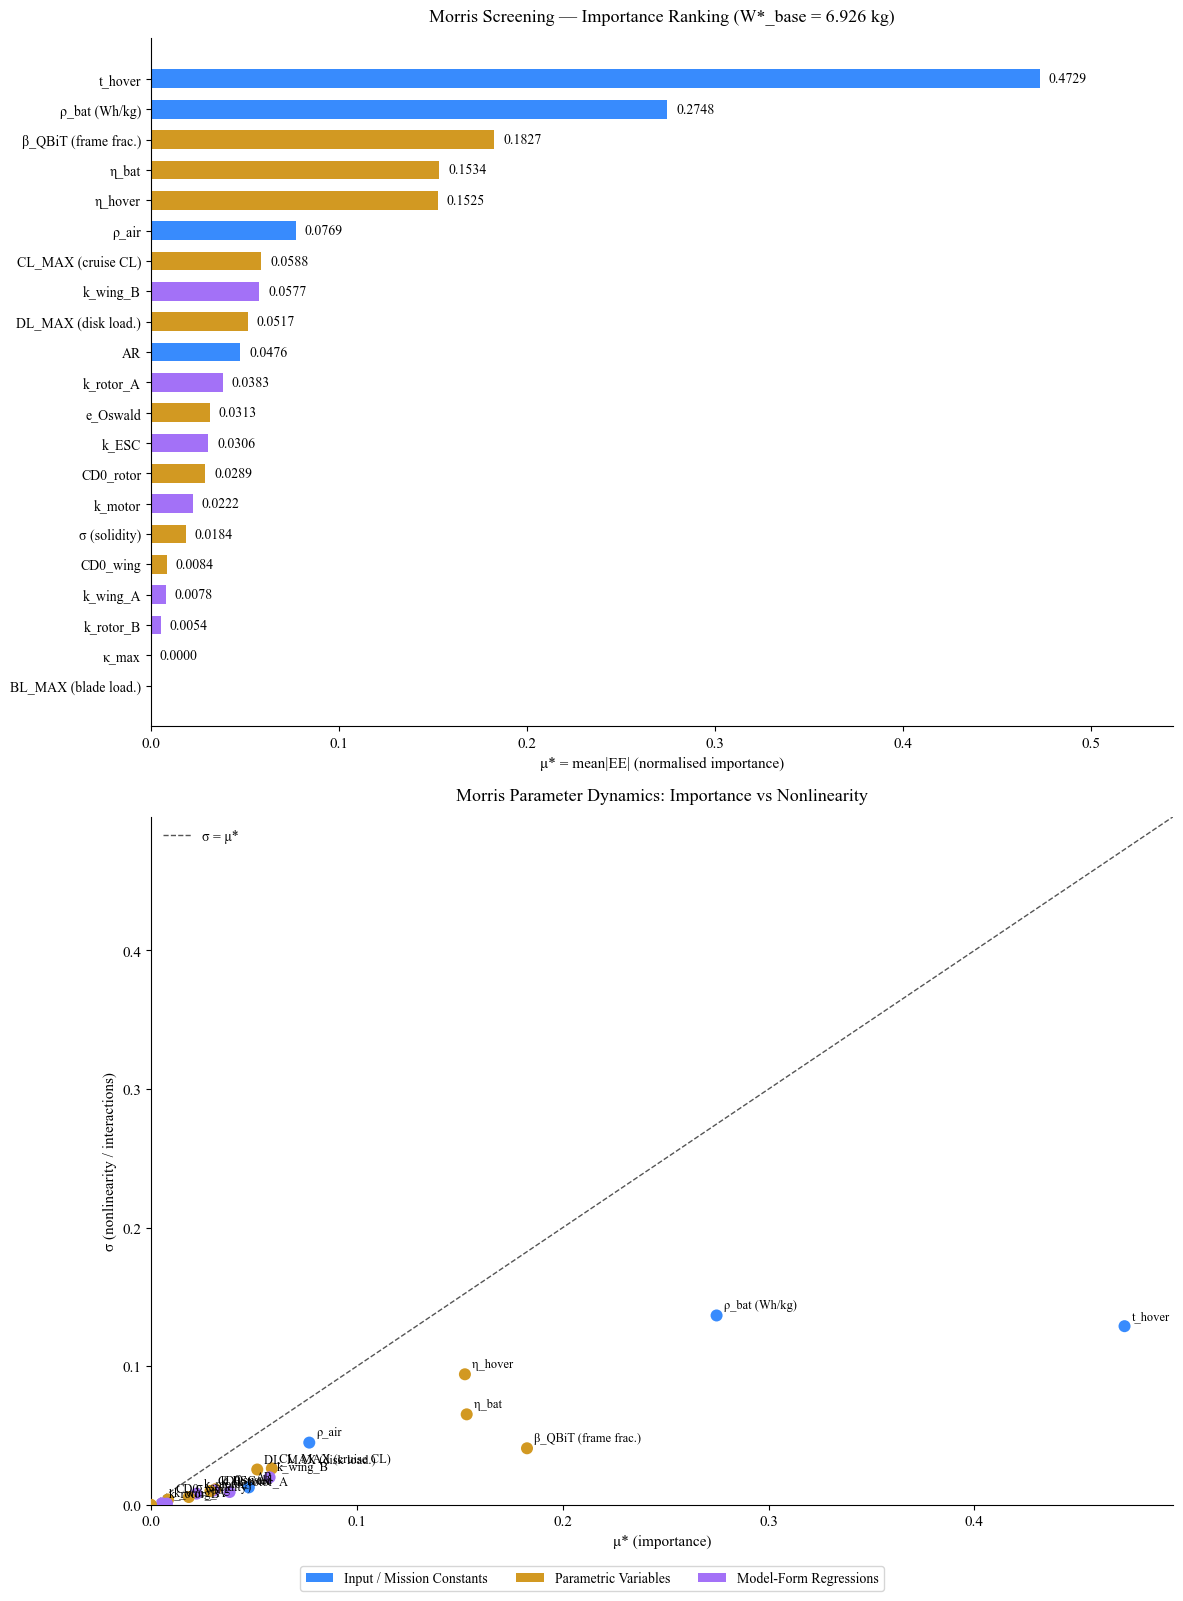


Processing complete. All Morris results displayed above.


In [151]:
import matplotlib.pyplot as plt

# Ensure plots display inline directly in the notebook
%matplotlib inline

# Set the seed
np.random.seed(SEED)

print("\n── QBiT UMDO Parameter Importance Screening ─────────────────────────")
print(f"   Method:   MORRIS")
print(f"   Mission:  payload={PAYLOAD_KG} kg  R={RANGE_M/1e3:.0f} km  n_c={N_C}")
print(f"   Evaluator: re-optimised W*_total (SLSQP, k={k} parameters)")
print("─────────────────────────────────────────────────────────────────────\n")

# ── Baseline ─────────────────────────────────────────────────────────────
print("Computing baseline W*_total …")
t0 = time.time()
W_base = compute_baseline()
print(f"  W*_base = {W_base/G:.4f} kg  ({time.time()-t0:.1f} s)\n")

if W_base < 1.0 * G or W_base > 500.0 * G:
    # Using RuntimeError instead of sys.exit(1) to avoid killing the notebook kernel
    raise RuntimeError(
        f"Baseline W*={W_base/G:.2f} kg is physically unreasonable.\n"
        "Check your qbit model and constants before proceeding."
    )

# ── Morris ───────────────────────────────────────────────────────────────
print("Running Morris screening …")
morris_results = run_morris(W_base)

# Display the data table directly in the notebook output
print_morris_table(morris_results, W_base)

# Render the plot inline
print("Generating Morris plots …")
plot_morris(morris_results, W_base)

print("\nProcessing complete. All Morris results displayed above.")